# Import das bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import re
from sklearn.model_selection import train_test_split

# Dataset Load

In [2]:
pd.set_option('display.max_colwidth', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [3]:
df = pd.read_csv('..\\data\\raw\\df_train.csv')

# Exploratory Data Analisys

## Descriptive statistics

In [4]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
0,26,62000,RENT,1.00,DEBTCONSOLIDATION,B,10000,11.26,0.16,N,2,0
1,23,39000,MORTGAGE,3.00,EDUCATION,C,5000,12.98,0.13,N,4,0
2,24,35000,RENT,1.00,DEBTCONSOLIDATION,A,12000,6.54,0.34,N,2,1
3,24,86000,RENT,1.00,HOMEIMPROVEMENT,B,12000,10.65,0.14,N,3,0
4,42,38400,RENT,4.00,MEDICAL,B,13000,NaN,0.34,N,11,1


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 22806 entries, 0 to 22805
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  22806 non-null  int64  
 1   person_income               22806 non-null  int64  
 2   person_home_ownership       22806 non-null  str    
 3   person_emp_length           22167 non-null  float64
 4   loan_intent                 22806 non-null  str    
 5   loan_grade                  22806 non-null  str    
 6   loan_amnt                   22806 non-null  int64  
 7   loan_int_rate               20606 non-null  float64
 8   loan_percent_income         22806 non-null  float64
 9   cb_person_default_on_file   22806 non-null  str    
 10  cb_person_cred_hist_length  22806 non-null  int64  
 11  loan_status                 22806 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 2.5 MB


In [6]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,loan_status
count,22806.00,22806.00,22167.00,22806.00,20606.00,22806.00,22806.00,22806.00
mean,27.72,66206.97,4.80,9598.74,11.01,0.17,5.80,0.22
std,6.34,63874.56,4.12,6313.13,3.23,0.11,4.06,0.41
min,20.00,4000.00,0.00,500.00,5.42,0.00,2.00,0.00
25%,23.00,38524.75,2.00,5000.00,7.90,0.09,3.00,0.00
50%,26.00,55000.00,4.00,8000.00,10.99,0.15,4.00,0.00
75%,30.00,79635.00,7.00,12250.00,13.47,0.23,8.00,0.00
max,144.00,6000000.00,123.00,35000.00,22.48,0.83,30.00,1.00


  * **`person_age`:** Registra uma idade máxima de 144 anos, um valor biologicamente impossível.
  * **`person_emp_length`:** Registra um tempo de emprego máximo de 123 anos, o que é logicamente impossível.
  * **`person_income`:** Exibe uma assimetria severa à direita, com média de ~$66.206,97 contra um valor máximo de $6.000.000,00, caracterizando um forte efeito de *outliers*.

In [7]:
print(f"Quantidade de linhas: {df.shape[0]}")
print(f"Quantidade de colunas: {df.shape[1]}")

Quantidade de linhas: 22806
Quantidade de colunas: 12


# Missing analisys

In [8]:
for col in df.columns:
    print(f'{col}: {df[col].isnull().sum()}')

person_age: 0
person_income: 0
person_home_ownership: 0
person_emp_length: 639
loan_intent: 0
loan_grade: 0
loan_amnt: 0
loan_int_rate: 2200
loan_percent_income: 0
cb_person_default_on_file: 0
cb_person_cred_hist_length: 0
loan_status: 0


In [9]:
cols_with_missing = []
for col in df.columns:
    if df[col].isnull().sum() > 0:
        cols_with_missing.append(col)
        print(f'========{col}========')
        print(df[col].value_counts(dropna=False))

========person_emp_length========
person_emp_length
0.00      2883
2.00      2695
3.00      2389
5.00      2068
4.00      2038
1.00      2006
6.00      1878
7.00      1537
8.00      1175
9.00       967
NaN        639
11.00      517
10.00      478
12.00      403
13.00      291
14.00      225
15.00      170
16.00      125
17.00       92
18.00       68
19.00       53
21.00       32
20.00       27
22.00       13
23.00        8
24.00        6
25.00        5
26.00        5
31.00        3
27.00        3
30.00        2
29.00        1
34.00        1
28.00        1
123.00       1
38.00        1
Name: count, dtype: int64
========loan_int_rate========
loan_int_rate
NaN      2200
10.99     547
7.51      502
7.88      448
7.49      436
         ... 
20.40       1
18.17       1
16.33       1
14.25       1
20.53       1
Name: count, Length: 331, dtype: int64


Uso do loop condicional com `isnull().sum()` indicando **2.200 valores nulos** para taxa de juros e **639** para tempo de emprego. O uso do `value_counts(dropna=False)` localizou uma linha contendo o ruído de 123.00 anos de tempo de serviço.

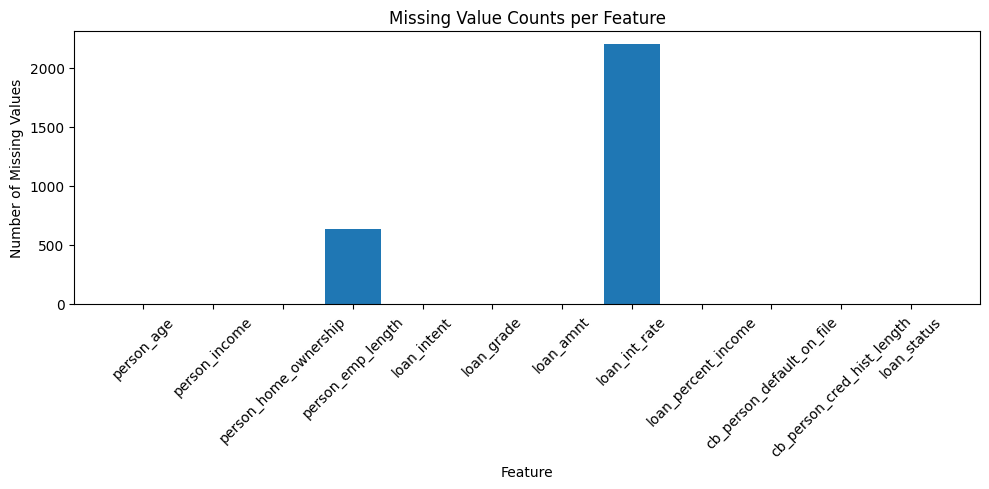

In [10]:

missing_counts = df.isnull().sum()

plt.figure(figsize=(10,5))
plt.bar(missing_counts.index, missing_counts.values)
plt.xticks(rotation=45)
plt.xlabel("Feature")
plt.ylabel("Number of Missing Values")
plt.title("Missing Value Counts per Feature")
plt.tight_layout()
plt.show()

A grande maioria das variáveis do dataset (10 das 12 colunas) está totalmente preenchida. Isso indica que o problema de dados faltantes está isolado e não generalizado.
* **Ponto Crítico de Ausência (`loan_int_rate`):** A coluna que mede a taxa de juros do empréstimo é a mais afetada, concentrando o maior volume de dados nulos do dataset (9,65%, o que equivale a 2.200 registros vazios).
* **Ponto Secundário de Ausência (`person_emp_length`):** A variável que indica o tempo de emprego apresenta um volume menor, mas ainda expressivo, de dados faltantes (2,80%, representando 639 registros vazios).

O gráfico deixa claro que o esforço de imputação e tratamento estatístico de dados ausentes deve ser direcionado a essas duas variáveis antes de avançar para a etapa de modelagem.

### Missing mechanisms

In [11]:
def detect_missing_mechanisms(df, alpha=0.05):
    """
    Analisa o DataFrame e indica o mecanismo de missing mais provável 
    para cada variável com dados ausentes, mostrando as relações
    estatísticas que justificam a classificação.
    """
    # Identifica colunas que têm dados nulos
    missing_cols = [col for col in df.columns if df[col].isnull().sum() > 0]
    
    if not missing_cols:
        print("Nenhuma variável possui dados ausentes")
        return None
    
    resultados = []
    
    for col in missing_cols:
        total_missing = df[col].isnull().sum()
        pct_missing = (total_missing / len(df)) * 100
        
        # Cria um indicador binário: 1 se for nulo, 0 se preenchido
        is_null = df[col].isnull().astype(int)
        
        mar_evidence = False
        colunas_relacionadas = []
        
        # Testa a coluna atual contra todas as outras do DataFrame
        for other_col in df.columns:
            if other_col == col:
                continue
                
            # Se a outra coluna for numérica -> Teste T de Student
            if pd.api.types.is_numeric_dtype(df[other_col]):
                grupo_presente = df[df[col].notnull()][other_col].dropna()
                grupo_ausente = df[df[col].isnull()][other_col].dropna()
                
                if len(grupo_presente) > 1 and len(grupo_ausente) > 1:
                    stat, p_val = stats.ttest_ind(grupo_presente, grupo_ausente, equal_var=False)
                    if p_val < alpha:
                        mar_evidence = True
                        colunas_relacionadas.append(f"{other_col} (p={p_val:.4f})")
            
            # Se a outra coluna for categórica/texto -> Teste Qui-Quadrado
            else:
                serie_categorica = df[other_col].astype(str).fillna('Missing_Val')
                contingency_table = pd.crosstab(is_null, serie_categorica)
                
                if contingency_table.size > 2:
                    chi2, p_val, dof, expected = stats.chi2_contingency(contingency_table)
                    if p_val < alpha:
                        mar_evidence = True
                        colunas_relacionadas.append(f"{other_col} (p={p_val:.4f})")
        
        # Definição do mecanismo e formatação da justificativa
        if mar_evidence:
            mecanismo = "MAR (Missing at Random)"
            # Mostra as duas principais variáveis que causaram o MAR (onde p < 0.05)
            justificativa = f"Depende de: {', '.join(colunas_relacionadas[:2])}"
        else:
            mecanismo = "MCAR ou MNAR"
            justificativa = "Sem relações estatísticas significativas (p >= 0.05)."
            
        resultados.append({
            'Variável': col,
            'Qtd Missing': total_missing,
            '% Missing': f"{pct_missing:.2f}%",
            'Mecanismo Provável': mecanismo,
            'Evidência Estatística (p < 0.05)': justificativa
        })
        
    return pd.DataFrame(resultados)

In [12]:
detect_missing_mechanisms(df)

,Variável,Qtd Missing,% Missing,Mecanismo Provável,Evidência Estatística (p < 0.05)
0,person_emp_length,639,2.80%,MAR (Missing at Random),"Depende de: person_income (p=0.0000), person_home_ownership (p=0.0000)"
1,loan_int_rate,2200,9.65%,MCAR ou MNAR,Sem relações estatísticas significativas (p >= 0.05).


## Conclusão Estatística dos Mecanismos (Validação Teórica)

A validação dos mecanismos seguiu estritamente os critérios metodológicos de análise de dados faltantes:

1. **`person_emp_length` classificada como MAR:** A hipótese de aleatoriedade foi rejeitada ($p = 0.0000$). A ausência é sistemática e previsível através das variáveis observadas `person_income` e `person_home_ownership`.
2. **`loan_int_rate` classificada estatisticamente como MCAR:** Não foram detectadas relações estatísticas significativas ($p \ge 0.05$) com as demais variáveis, indicando que a ausência não depende dos dados observados.

*Ressalva de MNAR: Alinhado com a teoria de que o mecanismo MNAR não pode ser verificado puramente por testes estatísticos, mantém-se a atenção contextual sobre a taxa de juros, dado que a omissão pode estar atrelada ao próprio valor oculto da taxa proposta.*

## Dataset inconsistencies

In [13]:
def detect_inconsistencies(df):
    """
    Varre o DataFrame em busca de inconsistências de digitação,
    como caracteres especiais em colunas numéricas (!, ?, letras),
    e reporta onde elas estão.
    """
    resultados = []
    
    
    for col in df.columns:
        # Se a coluna já foi detectada como numérica pura pelo Pandas
        if pd.api.types.is_numeric_dtype(df[col]):
            # Em colunas 100% numéricas, o maior risco são outliers bizarros (ex: idade negativa)
            valores_negativos = df[df[col] < 0][col].unique()
            if len(valores_negativos) > 0:
                resultados.append({
                    'Coluna': col,
                    'Tipo Identificado': str(df[col].dtype),
                    'Inconsistência Detectada': 'Valores numéricos negativos',
                    'Exemplos Encontrados': list(valores_negativos[:5]),
                    'Qtd Linhas Afetadas': df[df[col] < 0].shape[0]
                })
            continue
            
        # Se a coluna é do tipo texto/object (onde a sujeira costuma se esconder)
        else:
            # Copia e converte para string para aplicar Regex
            serie_str = df[col].astype(str).str.strip()
            
            # Testa se a coluna PARECE numérica, mas tem sujeira (ex: "25!", "120.00??", "35a")
            # Procura linhas que começam com números mas contêm letras ou símbolos de pontuação estranhos
            padrao_sujeira_num = r'^\d+.*[^\d\.\,\-].*$'
            mascara_sujeira = serie_str.str.contains(padrao_sujeira_num, regex=True, na=False)
            
            # Filtra os registros que caíram na máscara
            exemplos_sujeira = df[mascara_sujeira][col].unique()
            
            if len(exemplos_sujeira) > 0:
                resultados.append({
                    'Coluna': col,
                    'Tipo Identificado': 'Texto (Deveria ser Numérica?)',
                    'Inconsistência Detectada': 'Números misturados com letras/símbolos (!, ?, letras)',
                    'Exemplos Encontrados': list(exemplos_sujeira[:5]),
                    'Qtd Linhas Afetadas': df[mascara_sujeira].shape[0]
                })
                
            # Testas inconsistências em colunas puramente de texto (ex: loan_intent, loan_grade)
            # Busca por pontuações bizaras isoladas como "!??" ou "@" onde deveriam ser palavras
            padrao_pontuacao_bizarra = r'[\!\?\@\#\$\%\^\&\*]{2,}'
            mascara_pontuacao = serie_str.str.contains(padrao_pontuacao_bizarra, regex=True, na=False)
            exemplos_pontuacao = df[mascara_pontuacao][col].unique()
            
            if len(exemplos_pontuacao) > 0:
                resultados.append({
                    'Coluna': col,
                    'Tipo Identificado': str(df[col].dtype),
                    'Inconsistência Detectada': 'Símbolos/Pontuações repetidas ou inválidas',
                    'Exemplos Encontrados': list(examples_pontuacao[:5]),
                    'Qtd Linhas Afetadas': df[mascara_pontuacao].shape[0]
                })

    # Retorna o relatório formatado
    if resultados:
        # Força o Pandas a mostrar todo o texto sem cortar os exemplos
        pd.set_option('display.max_colwidth', None)
        return pd.DataFrame(resultados)
    else:
        print("Nenhuma inconsistência encontrada")
        return None

In [14]:
df_erros = detect_inconsistencies(df)
df_erros

Nenhuma inconsistência encontrada


In [15]:
def analisar_consistencia(df, max_unicos=30):
    """
    Analisa os valores únicos de cada variável para identificar possíveis
    erros de digitação e verifica a existência de linhas duplicadas.
    
    Parâmetros:
    - df: O DataFrame do Pandas que será analisado.
    - max_unicos: O limite de valores únicos para exibir os detalhes. 
                  Evita que colunas de ID ou texto livre poluam a tela.
    """
    print("=" * 60)
    print("ANÁLISE DE VALORES ÚNICOS (Busca por erros de digitação)")
    print("=" * 60)
    
    for coluna in df.columns:
        valores_unicos = df[coluna].unique()
        qtd_unicos = len(valores_unicos)
        tipo_dado = df[coluna].dtype
        
        print(f"\n🔹 Coluna: '{coluna}' | Tipo: {tipo_dado} \nTotal de Valores Únicos: {qtd_unicos}")
        
        # Se a coluna tiver poucos valores únicos, vale a pena inspecionar visualmente
        if qtd_unicos <= max_unicos:
            # Ordenamos para facilitar a identificação de palavras parecidas (ex: 'Sim', 'sim', 'siM')
            try:
                valores_ordenados = sorted(valores_unicos)
            except TypeError:
                # Caso a coluna misture tipos (ex: strings e NaN), o sorted falharia
                valores_ordenados = valores_unicos
                
            print(f"Valores: {valores_ordenados}")
        else:
            print(f"Mais de {max_unicos} valores únicos. \nAmostra dos 5 primeiros: {list(valores_unicos[:5])}")
            
    print("\n" + "=" * 60)
    print("ANÁLISE DE DUPLICATAS")
    print("=" * 60)
    
    total_duplicadas = df.duplicated().sum()
    
    if total_duplicadas > 0:
        print(f"Atenção: {total_duplicadas} linhas totalmente duplicadas no dataset.")
        print(f"Proporção de duplicatas: {(total_duplicadas / len(df)) * 100:.2f}% do dataset.")
    else:
        print("Nenhuma linha totalmente duplicada foi encontrada.")
    print("=" * 60)

In [16]:
analisar_consistencia(df)

ANÁLISE DE VALORES ÚNICOS (Busca por erros de digitação)

🔹 Coluna: 'person_age' | Tipo: int64 
Total de Valores Únicos: 53
Mais de 30 valores únicos. 
Amostra dos 5 primeiros: [np.int64(26), np.int64(23), np.int64(24), np.int64(42), np.int64(30)]

🔹 Coluna: 'person_income' | Tipo: int64 
Total de Valores Únicos: 3390
Mais de 30 valores únicos. 
Amostra dos 5 primeiros: [np.int64(62000), np.int64(39000), np.int64(35000), np.int64(86000), np.int64(38400)]

🔹 Coluna: 'person_home_ownership' | Tipo: str 
Total de Valores Únicos: 4
Valores: ['MORTGAGE', 'OTHER', 'OWN', 'RENT']

🔹 Coluna: 'person_emp_length' | Tipo: float64 
Total de Valores Únicos: 36
Mais de 30 valores únicos. 
Amostra dos 5 primeiros: [np.float64(1.0), np.float64(3.0), np.float64(4.0), np.float64(0.0), np.float64(11.0)]

🔹 Coluna: 'loan_intent' | Tipo: str 
Total de Valores Únicos: 6
Valores: ['DEBTCONSOLIDATION', 'EDUCATION', 'HOMEIMPROVEMENT', 'MEDICAL', 'PERSONAL', 'VENTURE']

🔹 Coluna: 'loan_grade' | Tipo: str 
Total

In [17]:
# cria um dataframe com as linhas duplicadas para análise posterior
df_duplicadas = df[df.duplicated()].sort_values(by=df.columns.tolist()).reset_index(drop=True)

# Diagnóstico e Plano de Tratamento

Após a execução da análise exploratória e estatística do conjunto de dados, foram identificadas inconsistências, dados ausentes (*missing data*) e duplicidades que exigem intervenção antes da etapa de modelagem. Abaixo, detalho o diagnóstico de cada resultado e as respectivas estratégias de tratamento adotadas.

---

### 1. Inconsistências e Outliers (`df.describe()`)

* **Idade do Solicitante (`person_age`):** O resumo estatístico revelou um valor máximo de **144 anos**. Sendo um valor biologicamente impossível, trata-se de um erro de registro ou ruído no dado.
    * **Estratégia:** Como o volume de registros nessa faixa é irrelevante frente ao total de dados, optou-se pela **remoção por filtragem** das linhas onde `person_age > 95`, evitando distorções no perfil demográfico.
* **Tempo de Emprego (`person_emp_length`):** Foi identificado um valor máximo de **123 anos** de tempo de serviço. Esta informação é logicamente inconsistente, uma vez que excede tanto a idade estimada dos proponentes quanto o tempo de vida laboral humano.
    * **Estratégia:** Os registros inconsistentes (ex: tempo de emprego maior que a idade atual ou valores absurdos acima de 60 anos) serão convertidos para valores nulos (`NaN`) para tratamento conjunto na etapa de imputação.
* **Renda Anual (`person_income`):** A variável apresenta uma forte assimetria positiva, com uma média de \$66.074,85 e um valor máximo de \$6.000.000,00. Embora valores multimilionários sejam teoricamente possíveis, eles atuam como *outliers* de alavancagem para modelos lineares.
    * **Estratégia:** Como será aplicada Regressão Logística, será aplicada uma **transformação logarítmica** (`np.log1p`) para normalizar a distribuição.

---

### 2. Análise de Dados Ausentes (*Missing Data*)

O *dataset* possui 22.806 linhas e o diagnóstico de nulidade apontou duas colunas afetadas. A investigação do comportamento dessas omissões foi conduzida por meio de testes de independência estatística para mapear seus respectivos mecanismos:

* **`person_emp_length` (2,80% de dados ausentes) $\rightarrow$ Mecanismo MAR (*Missing at Random*):** 
* **Diagnóstico Estatístico:** O teste rejeitou a hipótese de aleatoriedade pura ($p = 0.0000$), demonstrando uma relação sistemática onde a ausência do tempo de emprego é previsível e explicada pelas variáveis observadas `person_income` (Renda Anual) e `person_home_ownership` (Status de Habitação). Por apresentar baixo percentual de perda e um padrão MAR claro, a exclusão de linhas introduziria viés socioeconômico.
  * **Estratégia:** Será realizada uma **imputação por agrupamento (mediana condicional)**. Os valores nulos serão preenchidos utilizando a **mediana** do tempo de emprego segmentada por faixas etárias (`person_age`), garantindo coerência biológica e consistência interna ao registro.

* **`loan_int_rate` (9,65% de dados ausentes) $\rightarrow$ Mecanismo MCAR (*Missing Completely at Random*)**
* **Diagnóstico Estatístico:** O teste não detectou relações estatísticas significativas ($p \ge 0.05$) com nenhuma outra variável observada no *dataset*, o que teoricamente posiciona a taxa de juros sob o mecanismo **MCAR** (onde os dados observados assemelham-se a uma subamostra aleatória).
  * **Ressalva de Negócio (Risco de MNAR):** Alinhado à premissa de que o mecanismo **MNAR (*Missing Not at Random*)** não pode ser confirmado puramente por testes estatísticos, considera-se o viés de auto-seleção ou censura por conhecimento de domínio (ex: propostas omitidas porque as taxas oferecidas eram proibitivas para o cliente). Como quase 10% do conjunto de dados é afetado, a exclusão massiva dessas linhas introduziria um viés de seleção severo.
  * **Estratégia:** Aplicar **imputação condicional agrupada**, preenchendo os valores nulos com base na mediana da classe de risco do empréstimo (**`loan_grade`**). Esta abordagem preserva a forte indexação natural que existe entre a taxa de juros e o risco de crédito atribuído ao cliente, evitando a distorção da distribuição que ocorreria com uma imputação global simples.

### 3. Análise de Consistência Categórica (`df.unique()`)

* **Diagnóstico:** As variáveis categóricas (`person_home_ownership`, `loan_intent` e `loan_grade`) encontram-se perfeitamente limpas, sem problemas de strings duplicadas por espaçamento ou divergência de caixa (maiusculização/minusculização). 
* **Estratégia:** Na fase de pré-processamento para o modelo, será aplicado **One-Hot Encoding** para variáveis puramente nominais e **Ordinal Encoding** para a variável `loan_grade` (visto que as notas de 'A' a 'G' carregam uma ordem natural de risco de crédito).

---

### 4. Análise de Linhas Duplicadas (`df.duplicated()`)

* **Diagnóstico:** Foram identificadas mais de 72 linhas completamente duplicadas no DataFrame. A manutenção de registros idênticos distorce a distribuição de treino do modelo e induz ao fenômeno de *Data Leakage* (vazamento de dados) caso cópias idênticas sejam distribuídas entre os subconjuntos de treino e teste.
* **Estratégia:** **Remoção absoluta de duplicidades**, preservando apenas a primeira ocorrência (`df.drop_duplicates()`), garantindo a independência das observações.

---

### Pipeline Proposto

Para garantir a integridade estatística do modelo, mitigar o risco de *Data Leakage* (vazamento de dados) e respeitar a natureza dos mecanismos de ausência identificados, o fluxo de preparação de dados deve seguir estritamente a ordem abaixo:

1. **Remoção Absoluta de Duplicidades:**
   * `df.drop_duplicates(inplace=True)`
   * *Justificativa:* Elimina os mais de 160 registros perfeitamente idênticos antes de qualquer divisão ou cálculo estatístico, blindando o pipeline contra vazamento de dados entre os conjuntos de treino e teste.

2. **Sanitização e Tratamento de Limites Lógicos (Coerção para `NaN`):**
   * Filtragem de inconsistências extremas e biológicas: `person_age <= 95` e `person_emp_length < person_age`.
   * *Justificativa:* Isola os ruídos operacionais identificados (como idades de 144 anos e tempos de serviço de 123 anos). Ao transformar esses valores inconsistentes em `NaN`, eles passam a ser tratados de forma centralizada e padronizada junto com as omissões naturais na etapa seguinte.

3. **Imputação Estruturada por Medianas Condicionais:**
   * **`person_emp_length` (Mecanismo MAR):** Preenchimento dos dados faltantes utilizando a **mediana do tempo de emprego agrupada por faixas etárias** (`person_age`). Isso respeita a dependência socioeconômica observada no teste estatístico e garante coerência com o tempo de vida do cliente.
   * **`loan_int_rate` (Mecanismo MCAR / Risco de MNAR):** Preenchimento dos dados faltantes utilizando a **mediana da taxa de juros agrupada pela classe de risco do empréstimo** (`loan_grade`). Essa abordagem preserva a indexação financeira natural da taxa sem distorcer a variância global da feature.

4. **Codificação Categórica e Padronização Numérica:**
   * Aplicação de codificação de variáveis categóricas (ex: *One-Hot Encoding* ou *Ordinal Encoding*) e escala das variáveis numéricas (ex: *StandardScaler* ou *RobustScaler* para lidar com eventuais *outliers* remanescentes).
   * *Justificativa:* Preparação final dos dados na estrutura matemática exigida pelos algoritmos de Machine Learning, executada estritamente após a resolução completa de todos os dados ausentes e ruídos.